#### Import Necessary Library

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
import numpy as np
from scipy.stats import zscore

In [2]:
IMAGE_DATA_SET_PATH = 'output_mediapipe'
DATA_SET_KEYPOINT = 'model/keypoint_classifier/gesture_3/keypoint.csv'

## Show first 5 row of csv dataset

### There are 43 column with label class which is a record belong to

In [3]:
df = pd.read_csv(DATA_SET_KEYPOINT)
df.head()

,0,437,378,472,342,489,304,472.1,276,449,...,415,291,383,296,388,287,396,296.1,402.1,308
0,0,332,264,276,224,249,183,247,160,261,...,329,162,373,150,352,144,346,160,350,176
1,0,440,384,474,350,491,313,478,284,456,...,419,306,384,305,391,296,398,307,403,320
2,0,447,265,422,243,410,209,403,178,389,...,450,194,469,194,473,169,467,182,462,197
3,0,397,250,348,202,332,157,349,130,376,...,413,161,461,163,440,152,429,165,428,181
4,0,231,281,252,244,250,201,227,174,209,...,176,176,154,226,138,184,149,175,157,177


In [4]:
import pandas as pd

# Create column names
columns = ['class_label']
for i in range(21):
    columns += [f'landmark_{i}_x', f'landmark_{i}_y']

# Now read the CSV
df = pd.read_csv(DATA_SET_KEYPOINT, header=None, names=columns)

df.head()


,class_label,landmark_0_x,landmark_0_y,landmark_1_x,landmark_1_y,landmark_2_x,landmark_2_y,landmark_3_x,landmark_3_y,landmark_4_x,...,landmark_16_x,landmark_16_y,landmark_17_x,landmark_17_y,landmark_18_x,landmark_18_y,landmark_19_x,landmark_19_y,landmark_20_x,landmark_20_y
0,0,437,378,472,342,489,304,472,276,449,...,415,291,383,296,388,287,396,296,402,308
1,0,332,264,276,224,249,183,247,160,261,...,329,162,373,150,352,144,346,160,350,176
2,0,440,384,474,350,491,313,478,284,456,...,419,306,384,305,391,296,398,307,403,320
3,0,447,265,422,243,410,209,403,178,389,...,450,194,469,194,473,169,467,182,462,197
4,0,397,250,348,202,332,157,349,130,376,...,413,161,461,163,440,152,429,165,428,181


In [5]:
df.describe()

,class_label,landmark_0_x,landmark_0_y,landmark_1_x,landmark_1_y,landmark_2_x,landmark_2_y,landmark_3_x,landmark_3_y,landmark_4_x,...,landmark_16_x,landmark_16_y,landmark_17_x,landmark_17_y,landmark_18_x,landmark_18_y,landmark_19_x,landmark_19_y,landmark_20_x,landmark_20_y
count,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000,...,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000,74552.000000
mean,2.014419,313.634108,340.420955,313.354477,315.266673,313.701121,279.607308,314.799979,254.051387,316.511737,...,313.239886,271.506331,313.503380,264.884054,315.691343,249.911297,316.411029,259.458016,316.172363,265.405972
std,1.387438,107.560029,68.198120,103.846552,68.380700,103.095822,69.180196,103.453133,72.183968,107.263777,...,99.830177,71.882861,121.431823,73.613662,118.491868,76.665129,114.800678,81.023573,114.983356,86.596514
min,0.000000,32.000000,83.000000,26.000000,41.000000,24.000000,6.000000,0.000000,-12.000000,-40.000000,...,-19.000000,6.000000,-22.000000,-22.000000,-9.000000,-37.000000,-24.000000,-12.000000,-37.000000,-24.000000
25%,1.000000,226.000000,295.000000,230.000000,271.000000,237.000000,235.000000,240.000000,207.000000,237.000000,...,234.000000,226.000000,222.000000,218.000000,225.000000,200.000000,229.000000,204.000000,228.000000,205.000000
50%,2.000000,316.000000,345.000000,318.000000,319.000000,318.000000,282.000000,320.000000,256.000000,322.000000,...,315.000000,273.000000,312.000000,269.000000,314.000000,252.000000,314.000000,262.000000,314.000000,270.000000
75%,3.000000,404.000000,389.000000,397.000000,363.000000,389.000000,326.000000,391.000000,300.000000,398.000000,...,393.000000,317.000000,412.000000,314.000000,406.000000,300.000000,404.000000,313.000000,405.000000,323.000000
max,4.000000,614.000000,526.000000,610.000000,514.000000,623.000000,496.000000,626.000000,487.000000,640.000000,...,609.000000,571.000000,610.000000,497.000000,627.000000,510.000000,612.000000,544.000000,622.000000,564.000000


In [6]:
columns = df.columns[1:]

columns

Index(['landmark_0_x', 'landmark_0_y', 'landmark_1_x', 'landmark_1_y',
       'landmark_2_x', 'landmark_2_y', 'landmark_3_x', 'landmark_3_y',
       'landmark_4_x', 'landmark_4_y', 'landmark_5_x', 'landmark_5_y',
       'landmark_6_x', 'landmark_6_y', 'landmark_7_x', 'landmark_7_y',
       'landmark_8_x', 'landmark_8_y', 'landmark_9_x', 'landmark_9_y',
       'landmark_10_x', 'landmark_10_y', 'landmark_11_x', 'landmark_11_y',
       'landmark_12_x', 'landmark_12_y', 'landmark_13_x', 'landmark_13_y',
       'landmark_14_x', 'landmark_14_y', 'landmark_15_x', 'landmark_15_y',
       'landmark_16_x', 'landmark_16_y', 'landmark_17_x', 'landmark_17_y',
       'landmark_18_x', 'landmark_18_y', 'landmark_19_x', 'landmark_19_y',
       'landmark_20_x', 'landmark_20_y'],
      dtype='object')

## Check null and duplicate row in dataframe

#### Check null value

In [7]:
# Check for nulls in each column
null_counts = df.isnull().sum()
print("Null values per column:")
print(null_counts)

# OR check if any nulls at all
if df.isnull().values.any():
    print("⚠️ There are missing (null) values in the DataFrame.")
else:
    print("✅ No missing (null) values found.")


Null values per column:
class_label      0
landmark_0_x     0
landmark_0_y     0
landmark_1_x     0
landmark_1_y     0
landmark_2_x     0
landmark_2_y     0
landmark_3_x     0
landmark_3_y     0
landmark_4_x     0
landmark_4_y     0
landmark_5_x     0
landmark_5_y     0
landmark_6_x     0
landmark_6_y     0
landmark_7_x     0
landmark_7_y     0
landmark_8_x     0
landmark_8_y     0
landmark_9_x     0
landmark_9_y     0
landmark_10_x    0
landmark_10_y    0
landmark_11_x    0
landmark_11_y    0
landmark_12_x    0
landmark_12_y    0
landmark_13_x    0
landmark_13_y    0
landmark_14_x    0
landmark_14_y    0
landmark_15_x    0
landmark_15_y    0
landmark_16_x    0
landmark_16_y    0
landmark_17_x    0
landmark_17_y    0
landmark_18_x    0
landmark_18_y    0
landmark_19_x    0
landmark_19_y    0
landmark_20_x    0
landmark_20_y    0
dtype: int64
✅ No missing (null) values found.


#### Check duplicate value

In [8]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [9]:
duplicates = df[df.duplicated()]
print("Duplicate rows:")
print(duplicates)

Duplicate rows:
Empty DataFrame
Columns: [class_label, landmark_0_x, landmark_0_y, landmark_1_x, landmark_1_y, landmark_2_x, landmark_2_y, landmark_3_x, landmark_3_y, landmark_4_x, landmark_4_y, landmark_5_x, landmark_5_y, landmark_6_x, landmark_6_y, landmark_7_x, landmark_7_y, landmark_8_x, landmark_8_y, landmark_9_x, landmark_9_y, landmark_10_x, landmark_10_y, landmark_11_x, landmark_11_y, landmark_12_x, landmark_12_y, landmark_13_x, landmark_13_y, landmark_14_x, landmark_14_y, landmark_15_x, landmark_15_y, landmark_16_x, landmark_16_y, landmark_17_x, landmark_17_y, landmark_18_x, landmark_18_y, landmark_19_x, landmark_19_y, landmark_20_x, landmark_20_y]
Index: []

[0 rows x 43 columns]


In [10]:
df.drop_duplicates(inplace=False)
print(f"DataFrame shape after dropping duplicates: {df.shape}")

DataFrame shape after dropping duplicates: (74552, 43)


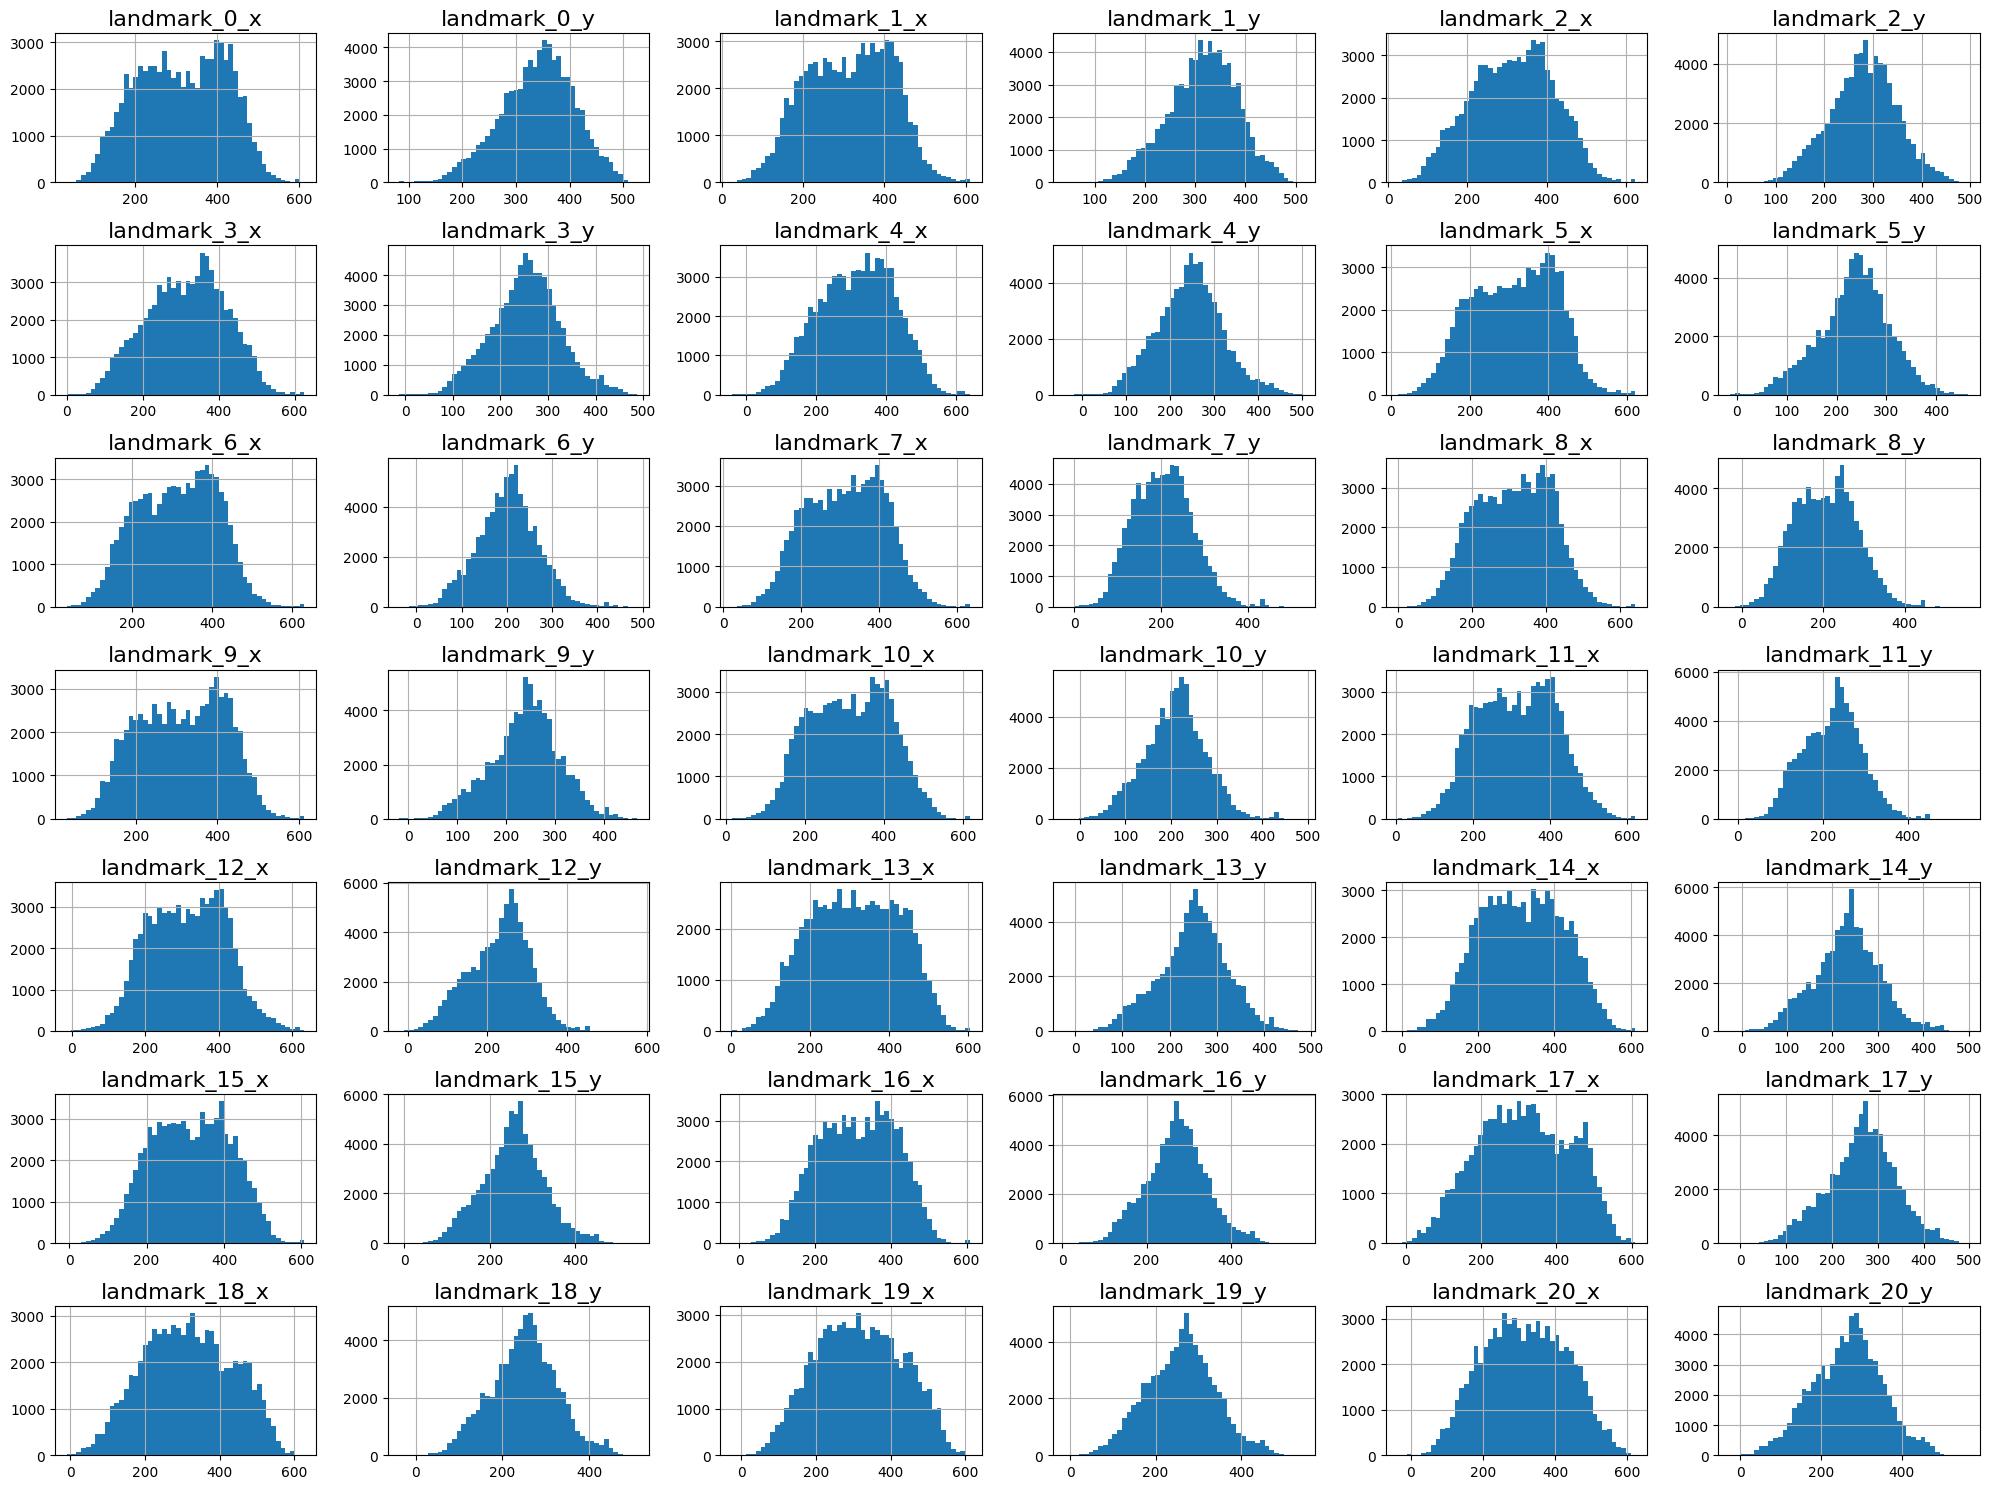

In [11]:
plt.rc('font', size=10)                  # Default font size for all text
plt.rc('axes', labelsize=16, titlesize=16)  # Font size for axes labels and titles
plt.rc('legend', fontsize=14)            # Font size for legend
plt.rc('xtick', labelsize=10)            # Font size for x-axis tick labels
plt.rc('ytick', labelsize=10)            # Font size for y-axis tick labels

# Plot histograms for each of the 42 columns in cleaned_df
# 'bins=50' means each histogram will have 50 bins
# 'figsize=(12, 8)' controls the size of the overall figure
df[columns].hist(bins=50, figsize=(20, 15))  # Adjusted size to better fit 42 plots

# Display the plots
plt.tight_layout()  # Prevent overlap between subplots
plt.show()

In [13]:
for col in columns:
    print(f"skewness value of ${col}: ",df[col].skew())

skewness value of $landmark_0_x:  -0.07630747337598895
skewness value of $landmark_0_y:  -0.2930278166034783
skewness value of $landmark_1_x:  -0.08256318711650967
skewness value of $landmark_1_y:  -0.26294578937777363
skewness value of $landmark_2_x:  -0.08114143753297429
skewness value of $landmark_2_y:  -0.1448939659088824
skewness value of $landmark_3_x:  -0.1084510834625809
skewness value of $landmark_3_y:  0.005399452024150336
skewness value of $landmark_4_x:  -0.10907042542389994
skewness value of $landmark_4_y:  0.0953132691934707
skewness value of $landmark_5_x:  -0.09635802904718768
skewness value of $landmark_5_y:  -0.21361580584260823
skewness value of $landmark_6_x:  -0.08187877225007559
skewness value of $landmark_6_y:  0.08819797554933953
skewness value of $landmark_7_x:  -0.06299618980820054
skewness value of $landmark_7_y:  0.2639502263378153
skewness value of $landmark_8_x:  -0.05872444816234218
skewness value of $landmark_8_y:  0.1407432486731511
skewness value of $l

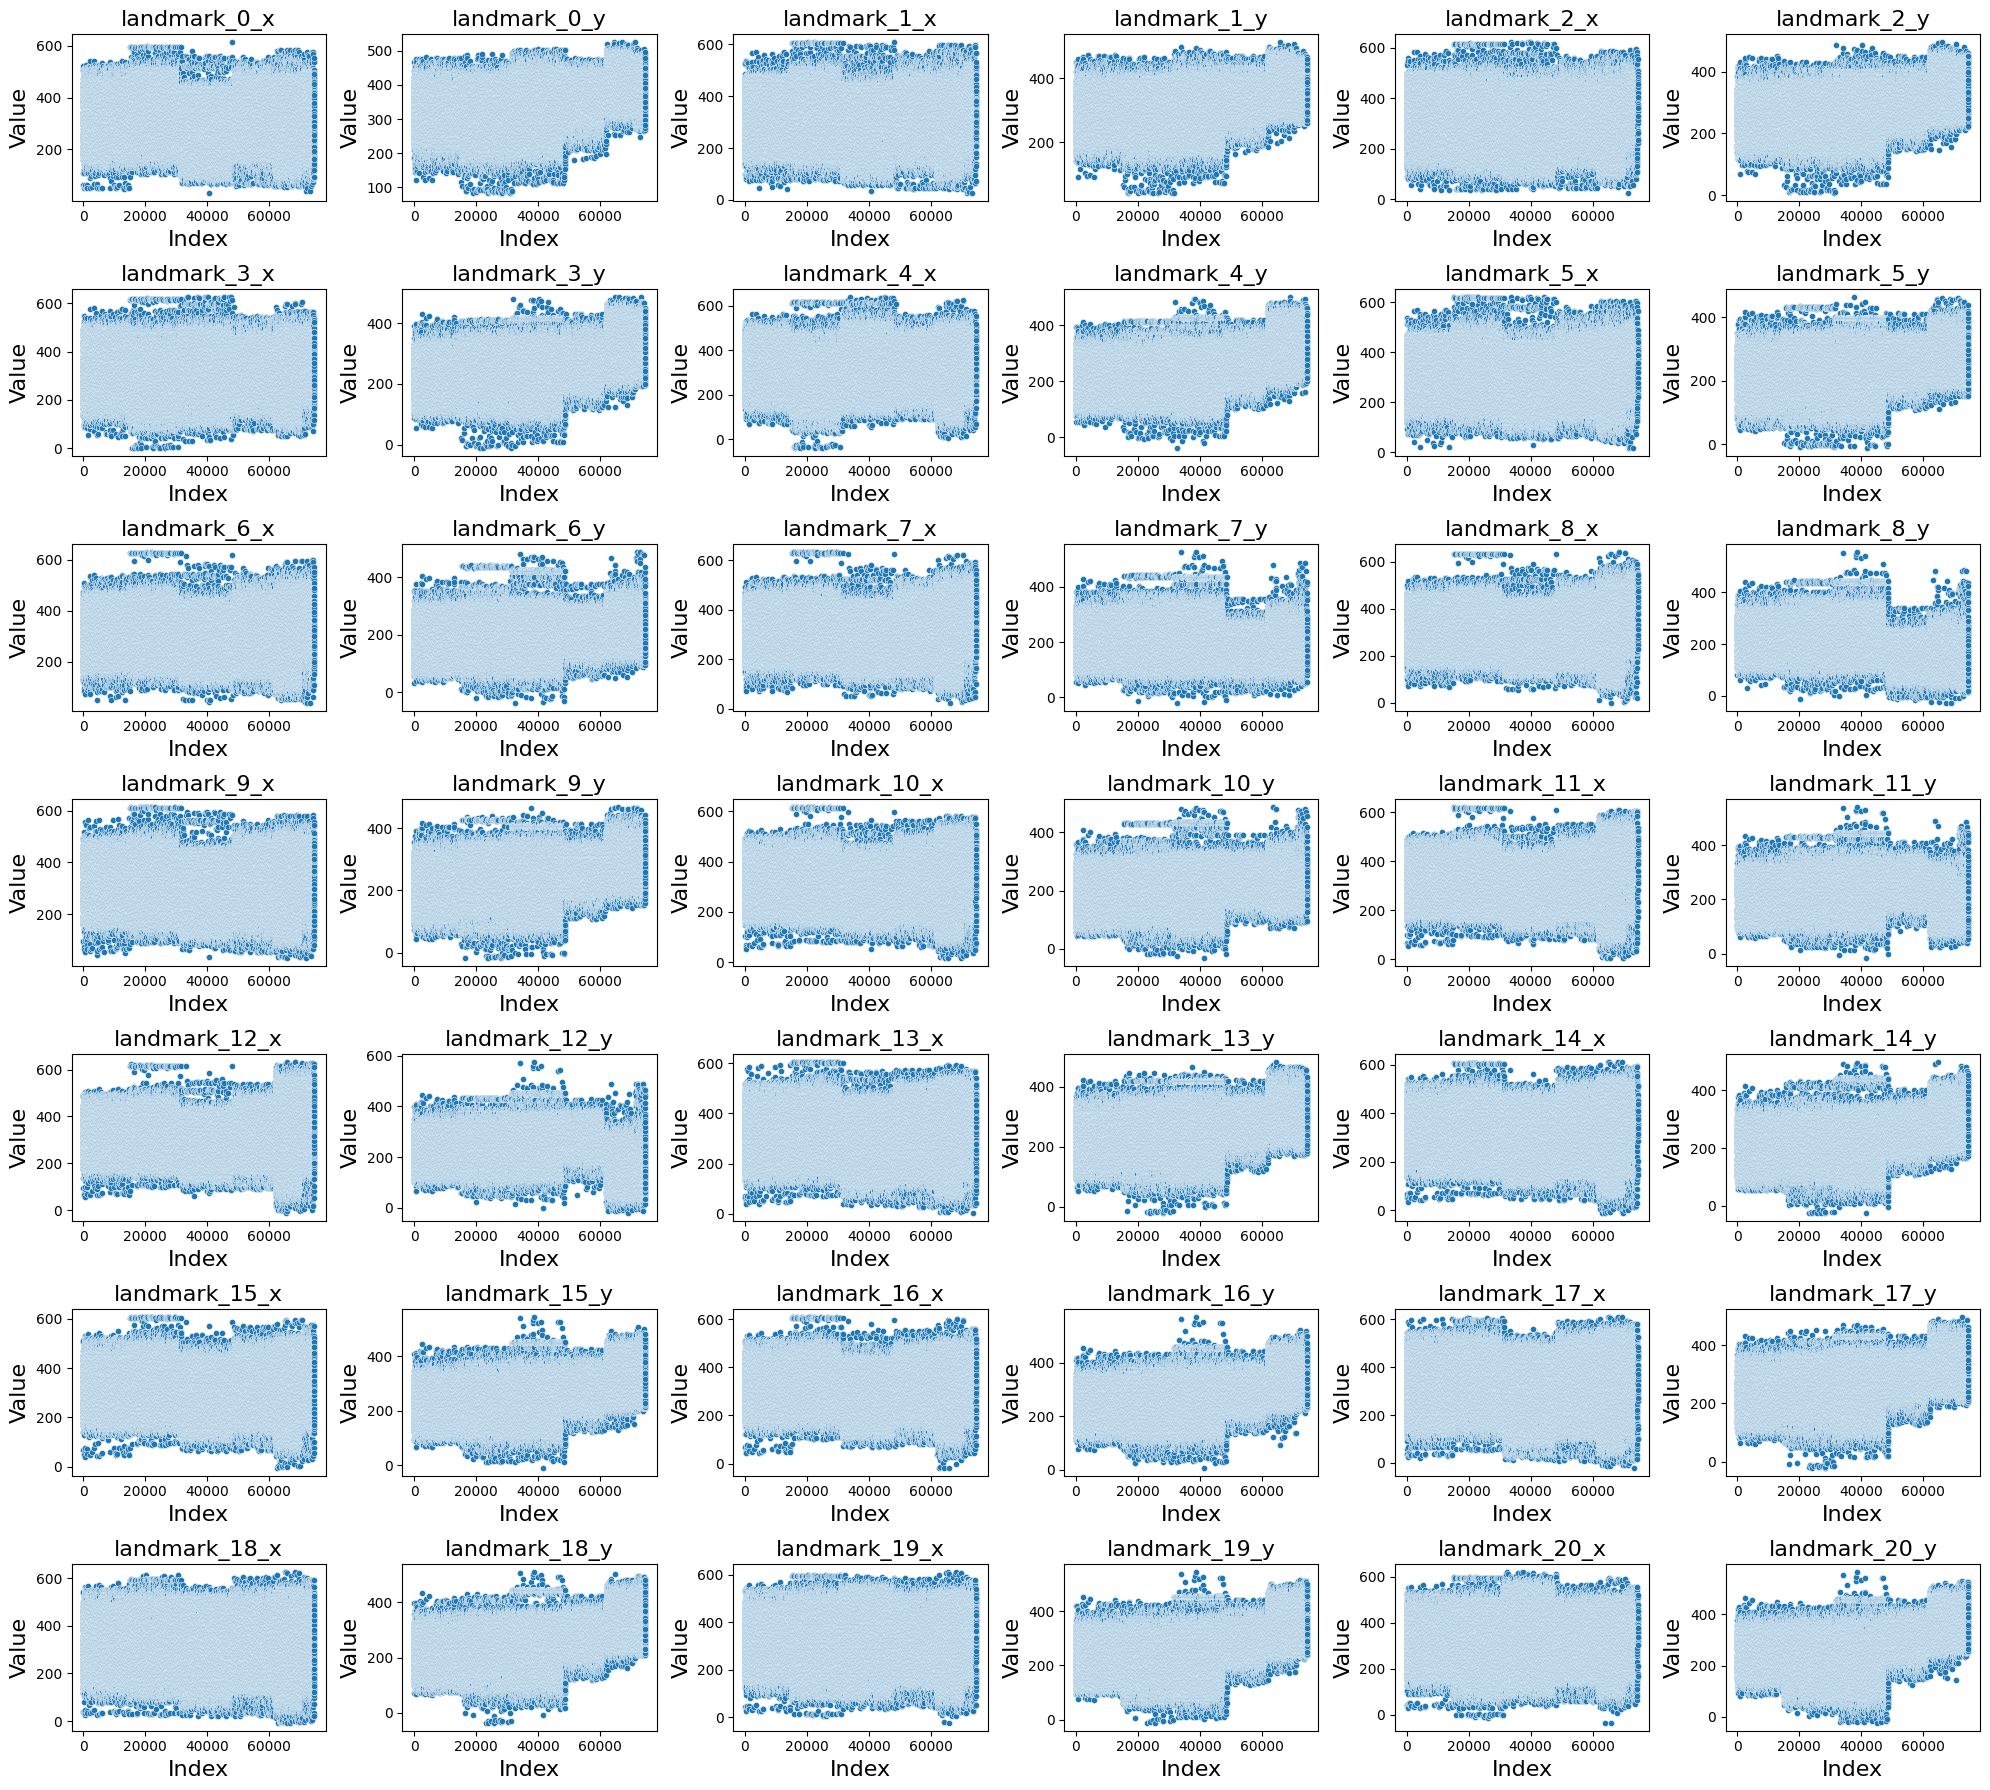

In [14]:
fig, axes = plt.subplots(7, 6, figsize=(20, 18))  # adjust grid size if needed

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through each column and plot it
for i, col in enumerate(columns):
    sns.scatterplot(x=range(len(df[col])), y=df[col], ax=axes[i], s=20)
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Index")
    axes[i].set_ylabel("Value")

# Remove any unused subplots (in case less than 42)
for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

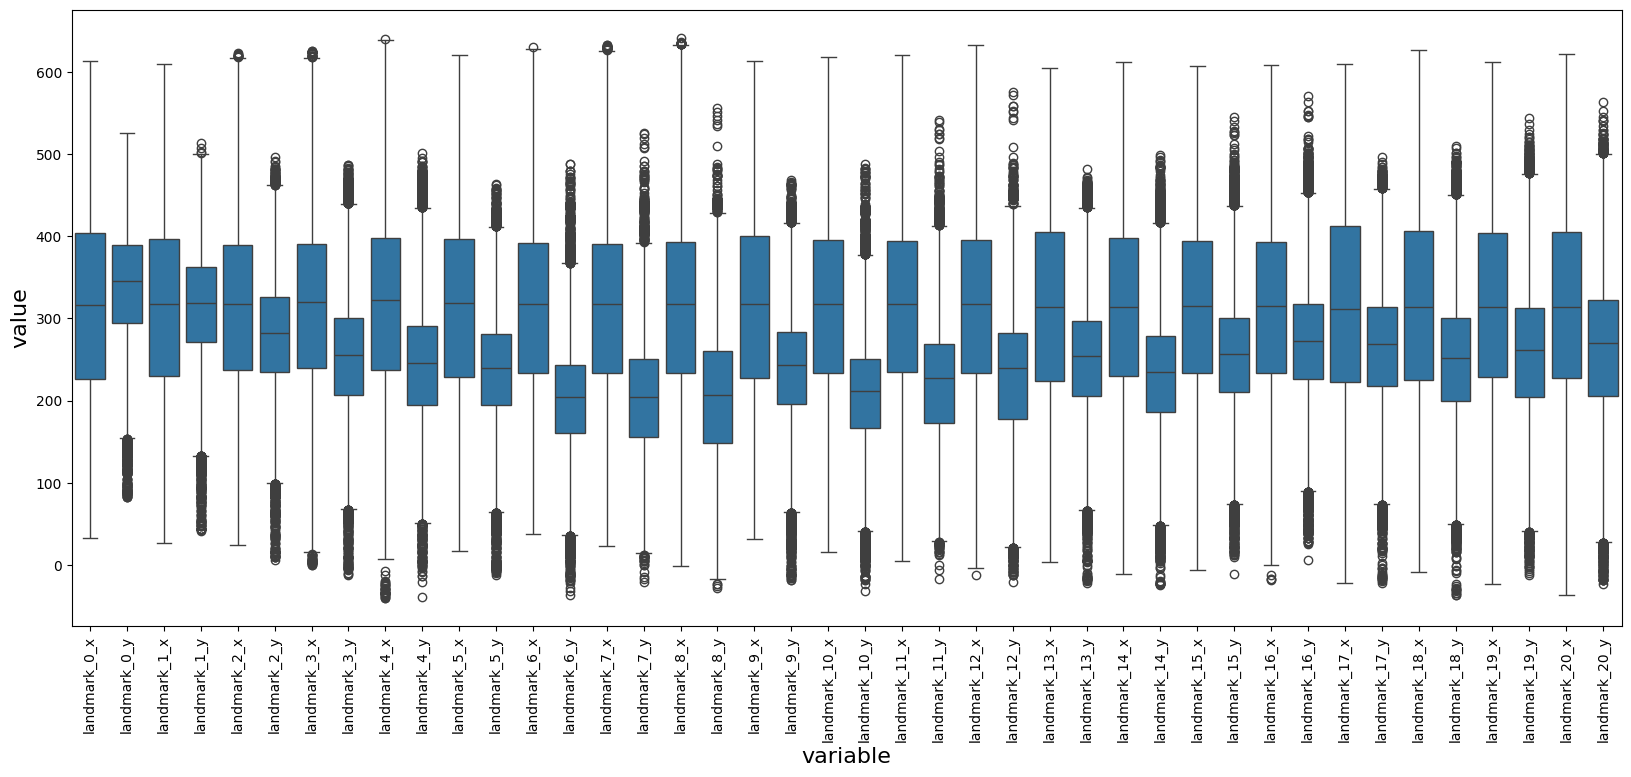

In [15]:
# Melt the DataFrame to long-form for seaborn boxplot
df_melted = df[columns].melt(var_name='variable', value_name='value')

# Plot
plt.figure(figsize=(20, 8))
sns.boxplot(x='variable', y='value', data=df_melted)
plt.xticks(rotation=90)
plt.show()

In [16]:
df[[f"{col}_zscore" for col in columns]] = df[columns].apply(zscore)

# Identify outliers
outlier_mask = (df[[f"{col}_zscore" for col in columns]] > 3.0) | \
               (df[[f"{col}_zscore" for col in columns]] < -3.0)

# Drop rows containing outliers
df_cleaned = df[~outlier_mask.any(axis=1)]
df_cleaned.drop(columns=[f"{col}_zscore" for col in columns], inplace=True)

/tmp/ipykernel_87431/3604027055.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.drop(columns=[f"{col}_zscore" for col in columns], inplace=True)


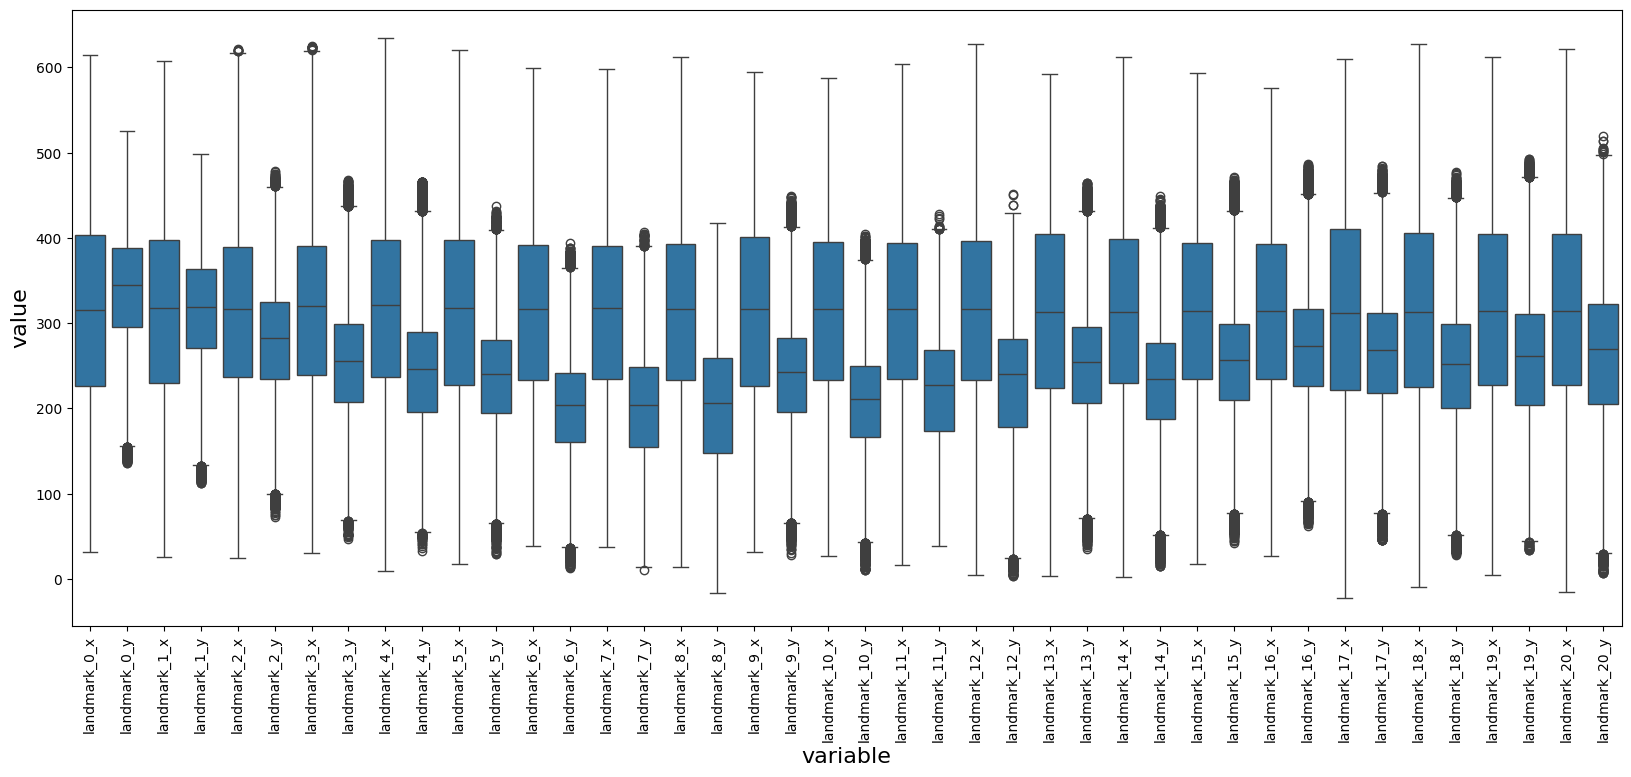

In [17]:
# Melt the DataFrame to long-form for seaborn boxplot
df_melted = df_cleaned[columns].melt(var_name='variable', value_name='value')

# Plot
plt.figure(figsize=(20, 8))
sns.boxplot(x='variable', y='value', data=df_melted)
plt.xticks(rotation=90)
plt.show()

In [ ]:
df_cleaned.count()

In [ ]:
df_cleaned.to_csv('model/keypoint_classifier/cleaned_keypoint_new.csv', index=False)

## Let Plot Qty of each class label

In [ ]:
cleaned_df = pd.read_csv('model/keypoint_classifier/cleaned_keypoint_new.csv')

In [ ]:
columns = cleaned_df.columns[1:]

columns

In [ ]:
# Load the CSV

# Replace 'class' with your actual label column name if different
label_column = 'class_label'  # Adjust this if needed

# Count the number of images per label
label_counts = cleaned_df[label_column].value_counts().sort_index()

# Extract labels and counts
labels = label_counts.index.tolist()
image_counts = label_counts.values.tolist()

# Plot the bar chart
plt.figure(figsize=(15, 6))
bars = plt.bar(labels, image_counts, color='skyblue')

# Add quantity labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, str(yval), ha='center', va='bottom')

plt.xlabel("Labels")
plt.ylabel("Number of Images")
plt.title("Image Count Per Label")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
cleaned_df.info()

In [ ]:
cleaned_df.describe()

In [ ]:
len(columns)

In [ ]:
# Set default font sizes for various plot elements for consistent styling
plt.rc('font', size=10)                  # Default font size for all text
plt.rc('axes', labelsize=16, titlesize=16)  # Font size for axes labels and titles
plt.rc('legend', fontsize=14)            # Font size for legend
plt.rc('xtick', labelsize=10)            # Font size for x-axis tick labels
plt.rc('ytick', labelsize=10)            # Font size for y-axis tick labels

# Plot histograms for each of the 42 columns in cleaned_df
# 'bins=50' means each histogram will have 50 bins
# 'figsize=(12, 8)' controls the size of the overall figure
cleaned_df.hist(bins=50, figsize=(20, 15))  # Adjusted size to better fit 42 plots

# Display the plots
plt.tight_layout()  # Prevent overlap between subplots
plt.show()


In [ ]:
plt.figure(figsize=(18, 18))
correlation = cleaned_df[columns].corr()
sns.heatmap(correlation, 
            xticklabels=correlation.columns.values,
            yticklabels=correlation.columns.values, annot=True)
plt.title('Heatmap of Correlation Matrix', fontweight='bold')
plt.show()

In [ ]:
ncols = 3
nrows = int(np.ceil(len(columns) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5))

axes = axes.flatten()

for i, column in enumerate(columns):
    sns.boxplot(data=cleaned_df[column], ax=axes[i])
    axes[i].set_ylabel("Values")
    axes[i].set_xlabel(column)

for i in range(len(cleaned_df), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()